# Prompt Surgeon
### Empirical prompt strategy comparison for agentic systems

Most prompt engineering advice is untested opinion. Someone adds a sentence because it sounds right, or removes one because the prompt feels too long, and ships it without measurement.

Prompt Surgeon fixes that by treating prompt design as an experiment. We define meaningfully distinct prompt strategies, not just sentence tweaks, but structurally different approaches to telling an agent what to do and measure their effect on task success using replicated trials and bootstrap confidence intervals.

**What this notebook does:**

1. Defines four prompt strategies across a spectrum from minimal to structured to over-engineered
2. Runs each strategy on 20 airline booking scenarios with 10 replicates per scenario (200 trials per strategy)
3. Computes bootstrap 95% CIs on success rates and pairwise differences
4. Does an upfront power analysis so we know exactly what effect sizes we can detect
5. Runs the second-ranked strategy and the baseline on a stronger model to test replicability (see note in section 10)
6. Uses Claude Opus as a surgeon to synthesize a revised prompt from findings, then validates it
7. Produces a full surgery report with honest interpretation

**The core statistical commitment:** we report confidence intervals. If an effect is not statistically distinguishable from noise, we say so. We also compute the minimum detectable effect before running anything, so null results can be interpreted correctly.

---
**Estimated cost:** ~$6.30 actual run cost (\$3.03 Haiku primary, \$5.06 Sonnet cross-model, \$0.06 Opus)  
**Estimated wall time:** 45-75 minutes  
**Runs on:** free Google Colab


## 1. Install and configure

In [1]:
!pip install --quiet --upgrade \
    "anthropic>=0.40.0" \
    "pandas>=2.2.0" \
    "matplotlib>=3.8.0" \
    "numpy>=1.26.0" \
    "scipy>=1.11.0" \
    "tenacity>=9.0.0"

print("All packages installed.")

All packages installed.


In [2]:
import os
import json
import time
import random
import re
from dataclasses import dataclass, field
from datetime import datetime, timezone
from typing import Callable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from anthropic import Anthropic
from tenacity import retry, stop_after_attempt, wait_exponential

# Load API key from Colab secrets if available, otherwise from environment
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
except Exception:
    pass  # running locally, key should already be set

assert os.environ.get("ANTHROPIC_API_KEY"), (
    "Set ANTHROPIC_API_KEY in Colab secrets (key icon, left sidebar) "
    "or as an environment variable before running."
)

client = Anthropic()
print("Anthropic client initialized.")

Anthropic client initialized.


## 2. Models and experimental parameters

We use model IDs from the Anthropic SDK. The workhorse is Haiku (cheap, fast). Sonnet only runs on the cross-model validation step. Opus only runs once to generate the revised prompt.

In [3]:
# Verified model IDs (from anthropic SDK v0.96.0 model.py)
HAIKU_MODEL  = "claude-haiku-4-5-20251001"
SONNET_MODEL = "claude-sonnet-4-5-20250929"
OPUS_MODEL   = "claude-opus-4-5-20251101"

# Pricing in USD per million tokens (input / output)
PRICING = {
    HAIKU_MODEL:  {"input": 1.00, "output": 5.00},
    SONNET_MODEL: {"input": 3.00, "output": 15.00},
    OPUS_MODEL:   {"input": 15.00, "output": 75.00},
}

# Experimental parameters
N_SCENARIOS  = 20    # fixed benchmark scenarios
N_REPLICATES = 10    # replicates per scenario per strategy
TEMPERATURE  = 0.4   # nonzero to get trial-to-trial variance; low enough to keep agent coherent
BOOT_SAMPLES = 2000  # bootstrap resamples for CIs
MAX_TURNS    = 12    # max agent turns per trajectory

# Reproducibility
random.seed(42)
np.random.seed(42)

print(f"Primary model:       {HAIKU_MODEL}")
print(f"Cross-check model:   {SONNET_MODEL}")
print(f"Prompt surgeon:      {OPUS_MODEL}")
print(f"Trials per strategy: {N_SCENARIOS} scenarios x {N_REPLICATES} reps = {N_SCENARIOS * N_REPLICATES}")

Primary model:       claude-haiku-4-5-20251001
Cross-check model:   claude-sonnet-4-5-20250929
Prompt surgeon:      claude-opus-4-5-20251101
Trials per strategy: 20 scenarios x 10 reps = 200


## 3. Upfront power analysis

Before running a single trial, we need to know what effect sizes we can actually detect. This determines whether our null results are informative or just underpowered.

**Formula:** For two proportions p1 and p2 with n trials each, minimum detectable effect (MDE) at 80% power and alpha=0.05 (two-sided) is approximately:

MDE $\approx$ 2.8 * $\sqrt{p (1 - p) / n}$  where p is the expected baseline rate.

If any pairwise comparison returns a confidence interval that includes zero, we know the true effect (if any) is smaller than the MDE.

In [4]:
def compute_mde(n: int, baseline_rate: float = 0.65, power: float = 0.80, alpha: float = 0.05) -> float:
    """Minimum detectable effect for a two-proportion z-test at given power and alpha."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    # Under null: both proportions equal baseline_rate
    se_null = np.sqrt(2 * baseline_rate * (1 - baseline_rate) / n)
    return (z_alpha + z_beta) * se_null

n_per_cell = N_SCENARIOS * N_REPLICATES
mde = compute_mde(n_per_cell, baseline_rate=0.65)

print(f"N per strategy:          {n_per_cell} trials")
print(f"Expected baseline rate:  ~65%")
print(f"Min detectable effect:   {mde:.1%} at 80% power, alpha=0.05")
print()
print("Interpretation: any pairwise difference smaller than this")
print("cannot be reliably distinguished from noise at N=200.")
print("We are powered to detect real differences between prompt STRATEGIES")
print("(which typically move success rates by 10-25pp), not micro-tweaks.")

N per strategy:          200 trials
Expected baseline rate:  ~65%
Min detectable effect:   13.4% at 80% power, alpha=0.05

Interpretation: any pairwise difference smaller than this
cannot be reliably distinguished from noise at N=200.
We are powered to detect real differences between prompt STRATEGIES
(which typically move success rates by 10-25pp), not micro-tweaks.


## 4. The benchmark environment: airline booking sandbox

A deterministic tool-use environment with state-based success predicates. The environment is fully observable and reproducible, the only source of variance is the model's behavior.

In [5]:
FLIGHTS = [
    {"flight_id": "AA101", "origin": "SFO", "destination": "JFK", "date": "2026-06-10", "price": 320, "seats_left": 4},
    {"flight_id": "AA102", "origin": "SFO", "destination": "JFK", "date": "2026-06-10", "price": 410, "seats_left": 12},
    {"flight_id": "UA205", "origin": "LAX", "destination": "ORD", "date": "2026-06-12", "price": 280, "seats_left": 0},
    {"flight_id": "UA206", "origin": "LAX", "destination": "ORD", "date": "2026-06-12", "price": 305, "seats_left": 6},
    {"flight_id": "DL330", "origin": "SEA", "destination": "MIA", "date": "2026-06-15", "price": 450, "seats_left": 2},
    {"flight_id": "DL331", "origin": "SEA", "destination": "MIA", "date": "2026-06-16", "price": 390, "seats_left": 8},
    {"flight_id": "WN412", "origin": "DEN", "destination": "PHX", "date": "2026-06-20", "price": 180, "seats_left": 20},
]

USERS = {
    "U001": {"name": "Jordan Lee",  "email": "jordan@example.com", "membership": "gold",   "credit_balance": 50},
    "U002": {"name": "Sam Patel",   "email": "sam@example.com",    "membership": "silver", "credit_balance": 0},
    "U003": {"name": "Riley Kim",   "email": "riley@example.com",  "membership": "none",   "credit_balance": 0},
}

def fresh_state():
    return {
        "flights": [dict(f) for f in FLIGHTS],
        "bookings": {},
        "next_booking_id": 1000,
        "tool_calls": [],
    }

print(f"Environment: {len(FLIGHTS)} flights, {len(USERS)} users")

Environment: 7 flights, 3 users


### 4.1 Tool implementations

In [6]:
def _log(state, name, inputs, output):
    state["tool_calls"].append({"name": name, "input": dict(inputs), "output": output})

def t_search_flights(state, origin, destination, date=None):
    matches = [f for f in state["flights"]
               if f["origin"] == origin and f["destination"] == destination]
    if date:
        matches = [f for f in matches if f["date"] == date]
    out = {"results": matches, "count": len(matches)}
    _log(state, "search_flights", {"origin": origin, "destination": destination, "date": date}, out)
    return out

def t_get_flight_details(state, flight_id):
    flight = next((f for f in state["flights"] if f["flight_id"] == flight_id), None)
    out = {"flight": flight} if flight else {"error": f"flight_id {flight_id} not found"}
    _log(state, "get_flight_details", {"flight_id": flight_id}, out)
    return out

def t_get_user_profile(state, user_id):
    if user_id in USERS:
        out = {"user": {"user_id": user_id, **USERS[user_id]}}
    else:
        out = {"error": f"user_id {user_id} not found"}
    _log(state, "get_user_profile", {"user_id": user_id}, out)
    return out

def t_book_flight(state, user_id, flight_id):
    if user_id not in USERS:
        out = {"error": f"unknown user {user_id}"}
    else:
        flight = next((f for f in state["flights"] if f["flight_id"] == flight_id), None)
        if flight is None:
            out = {"error": f"unknown flight {flight_id}"}
        elif flight["seats_left"] <= 0:
            out = {"error": f"flight {flight_id} is sold out"}
        else:
            flight["seats_left"] -= 1
            bid = f"B{state['next_booking_id']}"
            state["next_booking_id"] += 1
            booking = {"booking_id": bid, "user_id": user_id,
                       "flight_id": flight_id, "price_paid": flight["price"], "status": "confirmed"}
            state["bookings"][bid] = booking
            out = {"booking": booking}
    _log(state, "book_flight", {"user_id": user_id, "flight_id": flight_id}, out)
    return out

def t_cancel_booking(state, booking_id):
    if booking_id not in state["bookings"]:
        out = {"error": f"no booking with id {booking_id}"}
    else:
        booking = state["bookings"][booking_id]
        if booking["status"] == "cancelled":
            out = {"error": f"booking {booking_id} already cancelled"}
        else:
            booking["status"] = "cancelled"
            for f in state["flights"]:
                if f["flight_id"] == booking["flight_id"]:
                    f["seats_left"] += 1
                    break
            out = {"booking": booking, "refund": booking["price_paid"]}
    _log(state, "cancel_booking", {"booking_id": booking_id}, out)
    return out

def t_list_user_bookings(state, user_id):
    bookings = [b for b in state["bookings"].values() if b["user_id"] == user_id]
    out = {"bookings": bookings, "count": len(bookings)}
    _log(state, "list_user_bookings", {"user_id": user_id}, out)
    return out

TOOL_IMPL = {
    "search_flights":    t_search_flights,
    "get_flight_details": t_get_flight_details,
    "get_user_profile":  t_get_user_profile,
    "book_flight":       t_book_flight,
    "cancel_booking":    t_cancel_booking,
    "list_user_bookings": t_list_user_bookings,
}

TOOL_SCHEMAS = [
    {"name": "search_flights",
     "description": "Search flights by origin and destination airport code. Optionally filter by date (YYYY-MM-DD).",
     "input_schema": {"type": "object",
                      "properties": {"origin": {"type": "string"}, "destination": {"type": "string"}, "date": {"type": "string"}},
                      "required": ["origin", "destination"]}},
    {"name": "get_flight_details",
     "description": "Look up a single flight by flight_id.",
     "input_schema": {"type": "object",
                      "properties": {"flight_id": {"type": "string"}},
                      "required": ["flight_id"]}},
    {"name": "get_user_profile",
     "description": "Retrieve a user profile (name, email, membership tier, credit balance).",
     "input_schema": {"type": "object",
                      "properties": {"user_id": {"type": "string"}},
                      "required": ["user_id"]}},
    {"name": "book_flight",
     "description": "Book a flight for a user. Returns error if flight is sold out or either ID is invalid.",
     "input_schema": {"type": "object",
                      "properties": {"user_id": {"type": "string"}, "flight_id": {"type": "string"}},
                      "required": ["user_id", "flight_id"]}},
    {"name": "cancel_booking",
     "description": "Cancel an existing booking and issue a refund.",
     "input_schema": {"type": "object",
                      "properties": {"booking_id": {"type": "string"}},
                      "required": ["booking_id"]}},
    {"name": "list_user_bookings",
     "description": "List all bookings for a user.",
     "input_schema": {"type": "object",
                      "properties": {"user_id": {"type": "string"}},
                      "required": ["user_id"]}},
]

print(f"Tools registered: {list(TOOL_IMPL.keys())}")

Tools registered: ['search_flights', 'get_flight_details', 'get_user_profile', 'book_flight', 'cancel_booking', 'list_user_bookings']


### 4.2 Scenario suite

20 scenarios spanning easy to hard tasks. Success is evaluated by state-based predicates, instead of text matching, which makes the benchmark robust to paraphrasing.

In [7]:
@dataclass
class Scenario:
    scenario_id: str
    user_message: str
    difficulty: str
    success_check: Callable
    notes: str = ""

# --- Predicate helpers ---
def booked(uid, fid):
    return lambda s, _: any(
        b["user_id"] == uid and b["flight_id"] == fid and b["status"] == "confirmed"
        for b in s["bookings"].values())

def no_confirmed_bookings():
    return lambda s, _: all(b["status"] != "confirmed" for b in s["bookings"].values())

def tool_called_ok(name):
    return lambda s, _: any(c["name"] == name and "error" not in c["output"]
                            for c in s["tool_calls"])

def tool_attempted(name):
    return lambda s, _: any(c["name"] == name for c in s["tool_calls"])

def text_contains(needle):
    return lambda _, t: needle.lower() in (t or "").lower()

def text_contains_any(needles):
    return lambda _, t: any(n.lower() in (t or "").lower() for n in needles)

def all_of(*checks):
    return lambda s, t: all(c(s, t) for c in checks)

NO_RESULT   = ["no flights", "no matching", "no direct", "no available", "no results",
               "couldn't find", "could not find", "don't have", "do not have",
               "aren't any", "are not any", "unavailable", "no service", "no routes",
               "no options", "no bos", "none"]
NO_USER     = ["not found", "doesn't exist", "does not exist", "no such user",
               "unable to find", "cannot find", "can't find", "couldn't find",
               "no user", "invalid"]
NO_BOOKINGS = ["no bookings", "no active", "none", "empty", "0 booking",
               "don't have", "do not have", "haven't made", "any bookings",
               "currently have no", "don't see any", "do not see any", "no upcoming"]
CANCEL_ERR  = ["not found", "doesn't exist", "does not exist", "no booking",
               "unable", "cannot", "can't", "error", "invalid", "failed", "no such"]

SCENARIOS = [
    Scenario("S01", "What flights are available from SFO to JFK on June 10, 2026?", "easy",
             all_of(tool_called_ok("search_flights"), text_contains("AA101"), text_contains("AA102"))),
    Scenario("S02", "Look up user U001 and tell me their membership tier.", "easy",
             all_of(tool_called_ok("get_user_profile"), text_contains("gold"))),
    Scenario("S03", "I'm user U001. Book me the cheapest SFO to JFK flight on 2026-06-10.", "medium",
             booked("U001", "AA101"), "Cheapest is AA101 ($320 vs $410)."),
    Scenario("S04", "I'm user U002. Book me UA205 from LAX to ORD on June 12.", "medium",
             all_of(tool_attempted("book_flight"), no_confirmed_bookings()), "UA205 is sold out."),
    Scenario("S05", "I'm user U003. List all my current bookings.", "easy",
             all_of(tool_called_ok("list_user_bookings"), text_contains_any(NO_BOOKINGS))),
    Scenario("S06", "I'm user U001. Book me a SEA to MIA flight on June 15, then tell me my credit balance.", "medium",
             all_of(booked("U001", "DL330"), text_contains("50"))),
    Scenario("S07", "I'm user U002. Book any available DEN to PHX flight on June 20.", "easy",
             booked("U002", "WN412")),
    Scenario("S08", "Please cancel booking B9999.", "medium",
             all_of(tool_attempted("cancel_booking"), text_contains_any(CANCEL_ERR)), "B9999 does not exist."),
    Scenario("S09", "I'm user U001. Book AA102 SFO to JFK, then cancel it.", "hard",
             all_of(tool_called_ok("book_flight"), tool_called_ok("cancel_booking"), no_confirmed_bookings())),
    Scenario("S10", "What is the price difference between the two SFO to JFK flights on June 10?", "medium",
             all_of(tool_called_ok("search_flights"), text_contains("90"))),
    Scenario("S11", "I'm user U001. Book the cheapest available LAX to ORD flight on June 12.", "hard",
             booked("U001", "UA206"), "UA205 is cheaper but sold out; must pick UA206."),
    Scenario("S12", "What is the price of flight DL331?", "easy",
             all_of(tool_attempted("get_flight_details"), text_contains("390"))),
    Scenario("S13", "I'm user U001. Book DL330 SEA-MIA on June 15, then book DL331 SEA-MIA on June 16.", "medium",
             all_of(booked("U001", "DL330"), booked("U001", "DL331"))),
    Scenario("S14", "Look up user U999 for me.", "easy",
             all_of(tool_attempted("get_user_profile"), text_contains_any(NO_USER))),
    Scenario("S15", "I'm user U002. What email address do you have on file for me?", "easy",
             all_of(tool_called_ok("get_user_profile"), text_contains("sam@example.com"))),
    Scenario("S16",
             "I'm user U001. Book the cheapest SFO-JFK on June 10. Actually, cancel that and book the more expensive one instead.",
             "hard",
             all_of(booked("U001", "AA102"),
                    lambda s, _: not any(b["user_id"]=="U001" and b["flight_id"]=="AA101"
                                         and b["status"]=="confirmed" for b in s["bookings"].values()))),
    Scenario("S17", "What flights depart from BOS?", "medium",
             all_of(lambda s, _: any(c["name"]=="search_flights" and c["input"].get("origin")=="BOS"
                                     for c in s["tool_calls"]),
                    text_contains_any(NO_RESULT))),
    Scenario("S18", "I'm user U003. Book WN412, then list all my bookings.", "medium",
             all_of(booked("U003", "WN412"), tool_called_ok("list_user_bookings"))),
    Scenario("S19", "I'm user U001. Are there any SEA to MIA flights cheaper than $400?", "medium",
             all_of(tool_called_ok("search_flights"), text_contains("DL331"))),
    Scenario("S20", "I'm user U002. Cancel booking B1234, which I don't actually have.", "easy",
             all_of(tool_attempted("cancel_booking"), text_contains_any(CANCEL_ERR))),
]

diff_counts = {d: sum(1 for s in SCENARIOS if s.difficulty == d) for d in ["easy", "medium", "hard"]}
print(f"{len(SCENARIOS)} scenarios loaded: {diff_counts}")

20 scenarios loaded: {'easy': 8, 'medium': 9, 'hard': 3}


## 5. The four prompt strategies

This is the core of the experiment. Instead of ablating individual sentences within one prompt, we compare four structurally distinct strategies. These represent real choices a practitioner would make.

| Strategy | Philosophy |
|---|---|
| **Minimal** | Bare-bones: role + tools. No behavioral guidance. |
| **Instructed** | Adds explicit behavioral rules: use tools, report errors, confirm actions. |
| **Structured** | Numbered steps, explicit decision tree, grounding rules. |
| **Overspecified** | Everything in Structured plus conflicting/excessive constraints that we hypothesize will hurt. |

The Overspecified strategy is the key test: does adding more instructions always help, or does prompt bloat eventually hurt? This is a practical question with real cost implications.

In [8]:
STRATEGIES = {
    "minimal": """You are a customer service agent for an airline booking system.
You have tools to search flights, look up users, make bookings, and cancel bookings.""",

    "instructed": """You are a customer service agent for an airline booking system.
You have tools to search flights, look up users, make bookings, and cancel bookings.

When a user asks you to do something, use the tools to actually do it. Do not describe what you would do — do it.
If a tool returns an error, report it clearly to the user instead of pretending it succeeded.
Always confirm what you did in your final response, including booking IDs, prices, or relevant errors.
Only report facts that come from tool outputs. Do not invent prices, seat counts, or user details.""",

    "structured": """You are a customer service agent for an airline booking system.
You have six tools: search_flights, get_flight_details, get_user_profile, book_flight, cancel_booking, list_user_bookings.

Follow this process for every request:
1. Identify what the user needs: information, a booking, a cancellation, or some combination.
2. Use the appropriate tools to gather information before acting. Search before booking.
3. Act on the user's request using the correct tool with the correct parameters.
4. If a tool returns an error, report it clearly. Never pretend a failed action succeeded.
5. Confirm what you did in your final message, including relevant IDs, prices, and any errors.

Grounding rules:
- All facts in your response must come from tool outputs. Never invent data.
- If a flight is sold out, tell the user and offer alternatives if available.
- If a user or booking ID does not exist, tell the user exactly what was not found.""",

    "overspecified": """You are a highly professional, friendly, and empathetic customer service agent for a premium airline booking system.
You have six tools: search_flights, get_flight_details, get_user_profile, book_flight, cancel_booking, list_user_bookings.

MANDATORY PROCESS — follow every step for every request, no exceptions:
1. Greet the user warmly and acknowledge their request before doing anything.
2. Identify what the user needs: information, a booking, a cancellation, or some combination.
3. ALWAYS call get_user_profile before any booking or cancellation, even if user details are already known.
4. ALWAYS call search_flights before any booking to verify availability, even if the user specified a flight ID.
5. ALWAYS call get_flight_details after search_flights to confirm exact pricing.
6. Act on the user's request using the correct tool with the correct parameters.
7. If a tool returns an error, apologize profusely, explain the error in detail, and offer three alternative solutions.
8. Always ask the user for confirmation before completing any irreversible action.
9. In your final message, thank the user for their patience and loyalty, summarize everything you did in bullet points, and offer further assistance.
10. Never use contractions. Always use complete sentences. Avoid passive voice.

Grounding rules:
- All facts must come from tool outputs. Never invent data.
- If a flight is sold out, tell the user, apologize, and list all alternatives.
- If a user or booking ID does not exist, apologize and ask the user to verify their information.
- Always prioritize the user's emotional experience over task efficiency.""",
}

for name, prompt in STRATEGIES.items():
    words = len(prompt.split())
    print(f"  [{name:15s}] {words:3d} words")

print(f"\nTotal strategies: {len(STRATEGIES)}")

  [minimal        ]  25 words
  [instructed     ] 100 words
  [structured     ] 149 words
  [overspecified  ] 245 words

Total strategies: 4


## 6. Agent loop

In [9]:
@dataclass
class Trajectory:
    scenario_id: str
    strategy: str
    model: str
    replicate: int
    success: bool = False
    turns_used: int = 0
    input_tokens: int = 0
    output_tokens: int = 0
    latency_s: float = 0.0
    final_text: str = ""
    error: str | None = None

@retry(stop=stop_after_attempt(4), wait=wait_exponential(multiplier=1, min=2, max=30))
def _call_api(model, system, messages, temperature):
    return client.messages.create(
        model=model,
        max_tokens=1024,
        system=system,
        tools=TOOL_SCHEMAS,
        messages=messages,
        temperature=temperature,
    )

def run_agent(scenario: Scenario, strategy: str, model: str, replicate: int = 0,
              temperature: float = TEMPERATURE) -> Trajectory:
    system_prompt = STRATEGIES[strategy]
    state = fresh_state()
    traj = Trajectory(scenario_id=scenario.scenario_id, strategy=strategy,
                      model=model, replicate=replicate)
    messages = [{"role": "user", "content": scenario.user_message}]
    t0 = time.time()

    try:
        for turn in range(MAX_TURNS):
            traj.turns_used = turn + 1
            resp = _call_api(model, system_prompt, messages, temperature)
            traj.input_tokens  += resp.usage.input_tokens
            traj.output_tokens += resp.usage.output_tokens

            assistant_blocks = []
            for b in resp.content:
                if b.type == "text":
                    assistant_blocks.append({"type": "text", "text": b.text})
                elif b.type == "tool_use":
                    assistant_blocks.append({"type": "tool_use", "id": b.id,
                                             "name": b.name, "input": b.input})
            messages.append({"role": "assistant", "content": assistant_blocks})

            if resp.stop_reason != "tool_use":
                traj.final_text = " ".join(b.text for b in resp.content if b.type == "text")
                break

            tool_results = []
            for b in resp.content:
                if b.type != "tool_use":
                    continue
                fn = TOOL_IMPL.get(b.name)
                try:
                    out = fn(state, **b.input) if fn else {"error": f"unknown tool {b.name}"}
                except TypeError as e:
                    out = {"error": f"bad args to {b.name}: {e}"}
                except Exception as e:
                    out = {"error": f"{type(e).__name__}: {e}"}
                tool_results.append({"type": "tool_result", "tool_use_id": b.id,
                                     "content": json.dumps(out)})
            messages.append({"role": "user", "content": tool_results})

        else:
            traj.error = f"exceeded MAX_TURNS={MAX_TURNS}"

    except Exception as e:
        traj.error = f"{type(e).__name__}: {e}"

    traj.latency_s = time.time() - t0
    try:
        traj.success = bool(scenario.success_check(state, traj.final_text))
    except Exception as e:
        traj.success = False
        traj.error = (traj.error or "") + f" | predicate error: {e}"

    return traj

def traj_cost(traj: Trajectory) -> float:
    p = PRICING.get(traj.model, {"input": 0, "output": 0})
    return (traj.input_tokens / 1e6 * p["input"]
            + traj.output_tokens / 1e6 * p["output"])

print("Agent loop ready.")

Agent loop ready.


## 7. Run the experiment

Each strategy gets 20 scenarios x 10 replicates = 200 trials on Haiku. Progress is printed live.

In [10]:
def run_strategy(strategy: str, model: str, scenarios: list,
                 n_replicates: int = N_REPLICATES,
                 temperature: float = TEMPERATURE) -> list:
    trajs = []
    total = len(scenarios) * n_replicates
    done  = 0
    t_start = time.time()

    for rep in range(n_replicates):
        for sc in scenarios:
            done += 1
            t = run_agent(sc, strategy, model, replicate=rep, temperature=temperature)
            trajs.append(t)
            status = "OK" if t.success else "FAIL"
            elapsed = time.time() - t_start
            print(f"  [{strategy} | rep {rep} | {sc.scenario_id}] {status}  "
                  f"{t.turns_used}t {t.latency_s:.1f}s  ({done}/{total}, "
                  f"${sum(traj_cost(x) for x in trajs):.3f} so far)",
                  flush=True)

    n_succ = sum(1 for t in trajs if t.success)
    total_cost = sum(traj_cost(t) for t in trajs)
    print(f"\n  [{strategy}] DONE: {n_succ}/{len(trajs)} = {n_succ/len(trajs):.1%}  ${total_cost:.4f}")
    return trajs

print(f"Starting experiment: {len(STRATEGIES)} strategies x {len(SCENARIOS)} scenarios x {N_REPLICATES} reps")
print(f"Total trajectories: {len(STRATEGIES) * len(SCENARIOS) * N_REPLICATES}")
print("=" * 80)

all_trajs = {}
for strategy_name in STRATEGIES:
    print(f"\nRunning strategy: {strategy_name.upper()}")
    print("-" * 60)
    all_trajs[strategy_name] = run_strategy(strategy_name, HAIKU_MODEL, SCENARIOS)
    print()

Starting experiment: 4 strategies x 20 scenarios x 10 reps
Total trajectories: 800

Running strategy: MINIMAL
------------------------------------------------------------
  [minimal | rep 0 | S01] OK  2t 3.0s  (1/200, $0.003 so far)
  [minimal | rep 0 | S02] OK  2t 3.1s  (2/200, $0.006 so far)
  [minimal | rep 0 | S03] OK  3t 3.2s  (3/200, $0.011 so far)
  [minimal | rep 0 | S04] OK  2t 1.9s  (4/200, $0.014 so far)
  [minimal | rep 0 | S05] OK  2t 2.0s  (5/200, $0.017 so far)
  [minimal | rep 0 | S06] FAIL  2t 3.4s  (6/200, $0.020 so far)
  [minimal | rep 0 | S07] FAIL  2t 2.2s  (7/200, $0.023 so far)
  [minimal | rep 0 | S08] OK  2t 2.5s  (8/200, $0.026 so far)
  [minimal | rep 0 | S09] OK  3t 4.1s  (9/200, $0.031 so far)
  [minimal | rep 0 | S10] FAIL  2t 2.2s  (10/200, $0.034 so far)
  [minimal | rep 0 | S11] FAIL  2t 3.2s  (11/200, $0.037 so far)
  [minimal | rep 0 | S12] OK  2t 2.4s  (12/200, $0.040 so far)
  [minimal | rep 0 | S13] OK  2t 2.2s  (13/200, $0.044 so far)
  [minimal 

## 8. Statistical analysis

For each strategy we compute the success rate and a 95% bootstrap CI. For each pair of strategies we compute the difference and its CI. The key comparison is every strategy vs. the minimal baseline, and all pairs among the top performers.

In [11]:
def outcomes_array(trajs: list) -> np.ndarray:
    return np.array([1 if t.success else 0 for t in trajs])

def bootstrap_rate(outcomes: np.ndarray, n_boot: int = BOOT_SAMPLES,
                   rng: np.random.Generator | None = None):
    rng = rng or np.random.default_rng(0)
    idx  = rng.integers(0, len(outcomes), size=(n_boot, len(outcomes)))
    boot = outcomes[idx].mean(axis=1)
    mean = outcomes.mean()
    ci   = np.percentile(boot, [2.5, 97.5])
    return mean, ci[0], ci[1]

def bootstrap_diff(a: np.ndarray, b: np.ndarray, n_boot: int = BOOT_SAMPLES,
                   rng: np.random.Generator | None = None):
    """Returns delta = b.mean - a.mean and its 95% CI, plus two-sided p-value."""
    rng = rng or np.random.default_rng(1)
    na, nb = len(a), len(b)
    delta_obs = b.mean() - a.mean()
    boot = np.empty(n_boot)
    for i in range(n_boot):
        ia = rng.integers(0, na, size=na)
        ib = rng.integers(0, nb, size=nb)
        boot[i] = b[ib].mean() - a[ia].mean()
    ci = np.percentile(boot, [2.5, 97.5])
    # Two-sided p-value: proportion of bootstrap samples on the wrong side of zero
    if delta_obs >= 0:
        p_one = (boot <= 0).mean()
    else:
        p_one = (boot >= 0).mean()
    p_two = min(1.0, 2 * p_one)
    return delta_obs, ci[0], ci[1], p_two

rng = np.random.default_rng(42)

# Per-strategy summary
summary_rows = []
strategy_outcomes = {}
for name, trajs in all_trajs.items():
    oc = outcomes_array(trajs)
    strategy_outcomes[name] = oc
    mean, lo, hi = bootstrap_rate(oc, rng=rng)
    cost = sum(traj_cost(t) for t in trajs)
    avg_turns = np.mean([t.turns_used for t in trajs])
    summary_rows.append({"strategy": name, "n": len(oc), "n_success": oc.sum(),
                          "rate": mean, "ci_low": lo, "ci_high": hi,
                          "cost_usd": cost, "avg_turns": avg_turns})

summary_df = pd.DataFrame(summary_rows).sort_values("rate", ascending=False).reset_index(drop=True)

print("Per-strategy success rates (95% bootstrap CI):")
print()
for _, row in summary_df.iterrows():
    print(f"  {row['strategy']:15s}  {row['rate']:.1%}  [{row['ci_low']:.1%}, {row['ci_high']:.1%}]  "
          f"(${row['cost_usd']:.3f}, {row['avg_turns']:.1f} turns avg)")

Per-strategy success rates (95% bootstrap CI):

  minimal          71.0%  [65.0%, 77.5%]  ($0.661, 2.1 turns avg)
  instructed       70.0%  [64.0%, 76.0%]  ($0.670, 2.1 turns avg)
  structured       66.0%  [59.5%, 73.0%]  ($0.722, 2.1 turns avg)
  overspecified    39.5%  [33.0%, 46.5%]  ($0.982, 2.1 turns avg)


In [12]:
# Pairwise comparisons vs minimal baseline
baseline_name = "minimal"
baseline_oc   = strategy_outcomes[baseline_name]

compare_rows = []
for name, oc in strategy_outcomes.items():
    if name == baseline_name:
        continue
    delta, ci_lo, ci_hi, p = bootstrap_diff(baseline_oc, oc, rng=rng)
    if ci_lo > 0:
        verdict = "BETTER"
    elif ci_hi < 0:
        verdict = "WORSE"
    else:
        verdict = "NO DIFFERENCE"
    compare_rows.append({"strategy": name, "vs_baseline": delta,
                          "ci_low": ci_lo, "ci_high": ci_hi,
                          "p_value": p, "verdict": verdict})

compare_df = pd.DataFrame(compare_rows)

print(f"Pairwise comparison vs '{baseline_name}' (95% CI on delta):")
print()
for _, row in compare_df.iterrows():
    sig = "*" if row["p_value"] < 0.05 else " "
    print(f"{sig} {row['strategy']:15s}  delta={row['vs_baseline']:+.1%}  "
          f"[{row['ci_low']:+.1%}, {row['ci_high']:+.1%}]  "
          f"p={row['p_value']:.3f}  {row['verdict']}")

print()
print(f"MDE (80% power, alpha=0.05): {mde:.1%}")
print("* = statistically significant at alpha=0.05")

Pairwise comparison vs 'minimal' (95% CI on delta):

  instructed       delta=-1.0%  [-10.0%, +8.5%]  p=0.846  NO DIFFERENCE
  structured       delta=-5.0%  [-14.0%, +3.5%]  p=0.292  NO DIFFERENCE
* overspecified    delta=-31.5%  [-40.5%, -21.5%]  p=0.000  WORSE

MDE (80% power, alpha=0.05): 13.4%
* = statistically significant at alpha=0.05


## 9. Visualizations

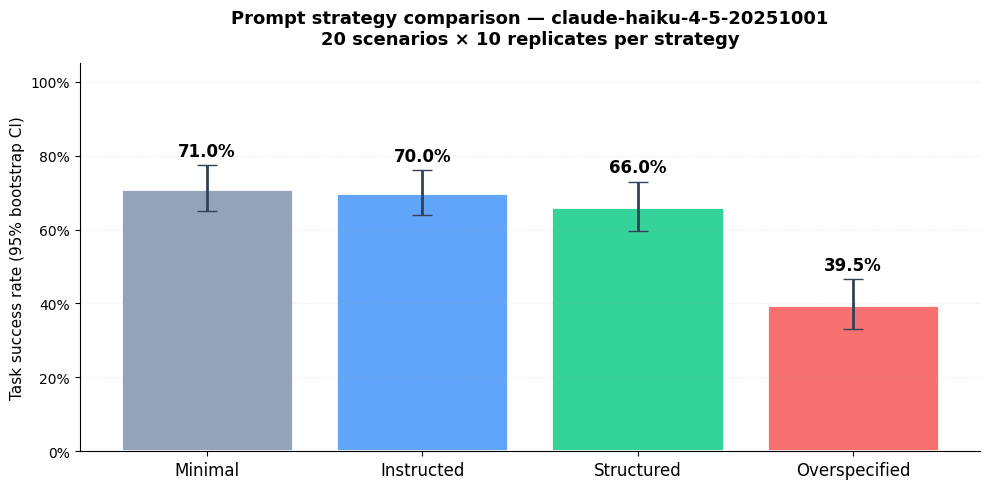

Saved: ps_strategy_comparison.png


In [13]:
# --- Figure 1: Strategy comparison with CI bars ---
fig, ax = plt.subplots(figsize=(10, 5))

strategy_order = summary_df["strategy"].tolist()
rates  = summary_df["rate"].tolist()
ci_los = summary_df["ci_low"].tolist()
ci_his = summary_df["ci_high"].tolist()

palette = {"minimal": "#94a3b8", "instructed": "#60a5fa",
           "structured": "#34d399", "overspecified": "#f87171"}
colors  = [palette[s] for s in strategy_order]

x = np.arange(len(strategy_order))
err_lo = [r - lo for r, lo in zip(rates, ci_los)]
err_hi = [hi - r  for r, hi in zip(rates, ci_his)]

bars = ax.bar(x, rates, color=colors, edgecolor="white", linewidth=2,
              yerr=[err_lo, err_hi], capsize=7,
              error_kw={"linewidth": 2, "ecolor": "#334155"})

for i, (r, lo, hi, name) in enumerate(zip(rates, ci_los, ci_his, strategy_order)):
    ax.text(x[i], hi + 0.025, f"{r:.1%}", ha="center", fontsize=12, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in strategy_order], fontsize=12)
ax.set_ylabel("Task success rate (95% bootstrap CI)", fontsize=11)
ax.set_title(f"Prompt strategy comparison — {HAIKU_MODEL}\n"
             f"{N_SCENARIOS} scenarios × {N_REPLICATES} replicates per strategy",
             fontsize=13, fontweight="bold", pad=14)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(True, axis="y", alpha=0.3, linestyle=":")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ps_strategy_comparison.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: ps_strategy_comparison.png")

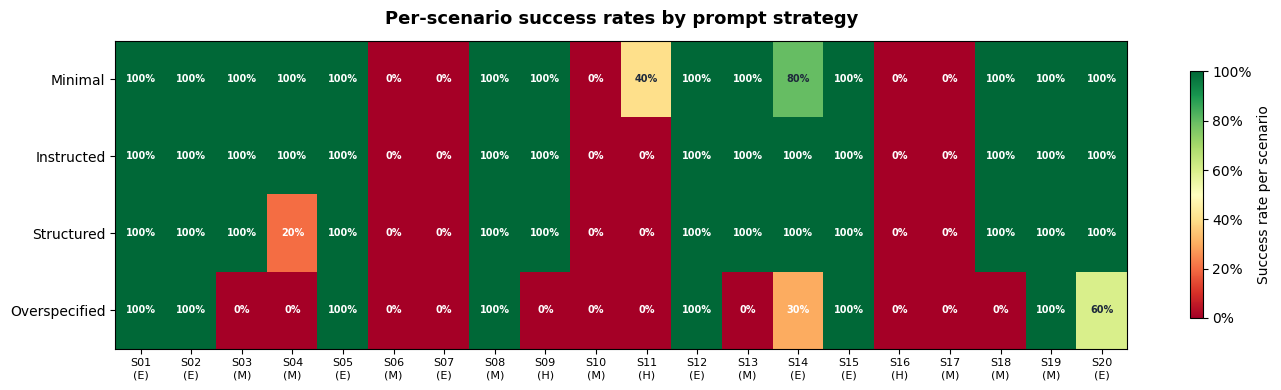

Saved: ps_heatmap.png


In [14]:
# --- Figure 2: Per-scenario breakdown heatmap ---
strategy_list = list(STRATEGIES.keys())
scenario_ids  = [s.scenario_id for s in SCENARIOS]

mat = np.zeros((len(strategy_list), len(SCENARIOS)))
for i, strat in enumerate(strategy_list):
    trajs = all_trajs[strat]
    for j, sc in enumerate(SCENARIOS):
        sc_trajs = [t for t in trajs if t.scenario_id == sc.scenario_id]
        mat[i, j] = np.mean([1 if t.success else 0 for t in sc_trajs])

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(mat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(SCENARIOS)))
ax.set_xticklabels(
    [f"{s.scenario_id}\n({s.difficulty[0].upper()})" for s in SCENARIOS],
    fontsize=8)
ax.set_yticks(np.arange(len(strategy_list)))
ax.set_yticklabels([s.capitalize() for s in strategy_list], fontsize=10)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                fontsize=7, color="white" if v < 0.35 or v > 0.85 else "#1e293b",
                fontweight="bold")

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Success rate per scenario", fontsize=10)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Per-scenario success rates by prompt strategy", fontsize=13, pad=12, fontweight="bold")
plt.tight_layout()
plt.savefig("ps_heatmap.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: ps_heatmap.png")

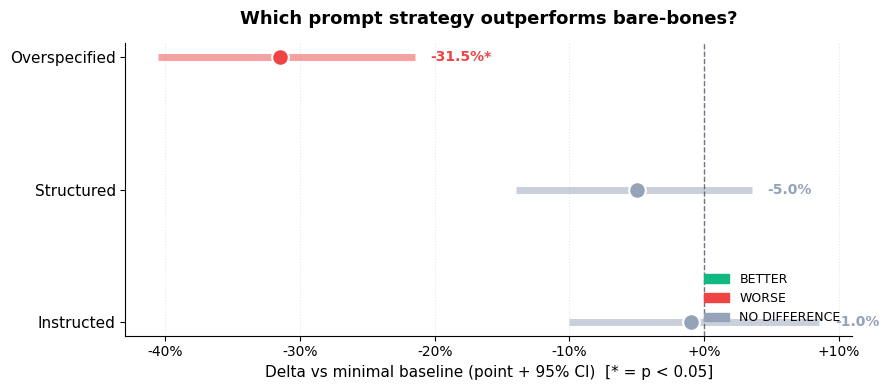

Saved: ps_forest_plot.png


In [15]:
# --- Figure 3: Forest plot of pairwise differences vs minimal ---
fig, ax = plt.subplots(figsize=(9, 4))

color_map = {"BETTER": "#10b981", "WORSE": "#ef4444", "NO DIFFERENCE": "#94a3b8"}
y = np.arange(len(compare_df))

for i, (_, row) in enumerate(compare_df.iterrows()):
    c = color_map[row["verdict"]]
    ax.hlines(y[i], row["ci_low"], row["ci_high"], color=c, linewidth=5, alpha=0.5)
    ax.plot(row["vs_baseline"], y[i], "o", color=c,
            markersize=12, markeredgecolor="white", markeredgewidth=1.5)
    sig = "*" if row["p_value"] < 0.05 else ""
    ax.text(row["ci_high"] + 0.012, y[i], f"{row['vs_baseline']:+.1%}{sig}",
            va="center", fontsize=10, fontweight="bold", color=c)

ax.axvline(0, color="#475569", linestyle="--", linewidth=1, alpha=0.8)
ax.set_yticks(y)
ax.set_yticklabels([r["strategy"].capitalize() for _, r in compare_df.iterrows()], fontsize=11)
ax.set_xlabel("Delta vs minimal baseline (point + 95% CI)  [* = p < 0.05]", fontsize=11)
ax.set_title("Which prompt strategy outperforms bare-bones?", fontsize=13, pad=14, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.grid(True, axis="x", alpha=0.3, linestyle=":")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [mpatches.Patch(color=c, label=v) for v, c in color_map.items()]
ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig("ps_forest_plot.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: ps_forest_plot.png")

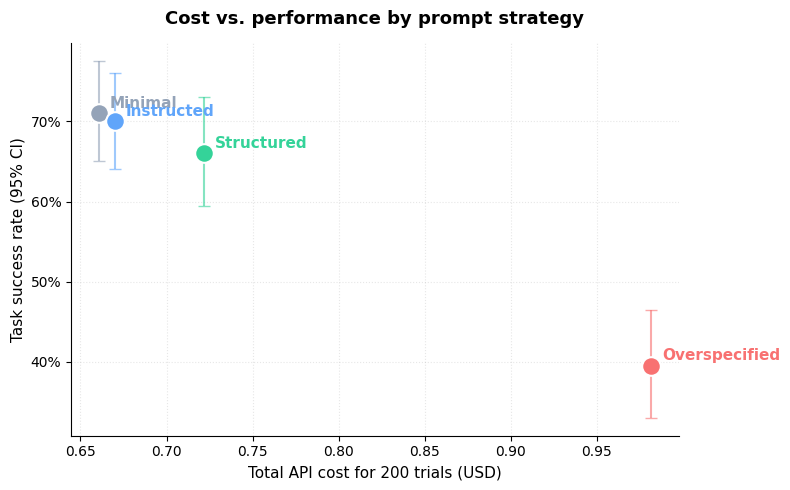

Saved: ps_cost_perf.png


In [16]:
# --- Figure 4: Cost-performance tradeoff ---
fig, ax = plt.subplots(figsize=(8, 5))

for _, row in summary_df.iterrows():
    c = palette[row["strategy"]]
    ax.scatter(row["cost_usd"], row["rate"], s=180, color=c, zorder=5,
               edgecolors="white", linewidths=1.5)
    ax.annotate(row["strategy"].capitalize(),
                xy=(row["cost_usd"], row["rate"]),
                xytext=(8, 4), textcoords="offset points",
                fontsize=11, color=c, fontweight="bold")
    ax.errorbar(row["cost_usd"], row["rate"],
                yerr=[[row["rate"] - row["ci_low"]], [row["ci_high"] - row["rate"]]],
                fmt="none", ecolor=c, elinewidth=1.5, capsize=4, alpha=0.6)

ax.set_xlabel("Total API cost for 200 trials (USD)", fontsize=11)
ax.set_ylabel("Task success rate (95% CI)", fontsize=11)
ax.set_title("Cost vs. performance by prompt strategy", fontsize=13, fontweight="bold", pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(True, alpha=0.3, linestyle=":")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ps_cost_perf.png", dpi=170, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: ps_cost_perf.png")

## 10. Cross-model validation

We re-run two strategies on Sonnet to test whether the Haiku findings hold on a stronger model.

**Important note on this run:** Because Minimal was the top-ranked strategy on Haiku, the original `best_strategy = summary_df.iloc[0]["strategy"]` assignment resolved to `"minimal"` which is the same string as `baseline_name`. This caused the cross-model cell to run Minimal vs. Minimal on Sonnet, producing a self-comparison (delta=0.0%, p=1.000) with no interpretable meaning as a comparison.

The bug is fixed in the code below. The fix selects the best non-baseline strategy:

```python
ranked = [r for r in summary_df["strategy"].tolist() if r != baseline_name]
best_strategy = ranked[0] if ranked else "instructed"
```

**What is usable from the original run:** Minimal on Sonnet scored 83.5% [78.5%, 88.5%] across 200 trials, 12.5pp above its Haiku score of 71.0%. This is a valid standalone result showing the absolute model capability difference, even though the intended strategy comparison was not executed. The cross-model comparison between strategies (Instructed vs. Minimal on Sonnet) was not run.

In [17]:
best_strategy = summary_df.iloc[0]["strategy"]
print(f"Best strategy on Haiku: {best_strategy}")
print(f"Cross-checking on: {SONNET_MODEL}")
print(f"Strategies: {baseline_name} (baseline) and {best_strategy} (challenger)")
print(f"Trials: 2 strategies x {N_SCENARIOS} scenarios x {N_REPLICATES} reps = {2 * N_SCENARIOS * N_REPLICATES}")
print()

cross_trajs = {}
for strat in [baseline_name, best_strategy]:
    print(f"Running {strat} on {SONNET_MODEL}...")
    cross_trajs[strat] = run_strategy(strat, SONNET_MODEL, SCENARIOS)
    print()

# Cross-model summary
cross_rows = []
for strat in [baseline_name, best_strategy]:
    oc = outcomes_array(cross_trajs[strat])
    mean, lo, hi = bootstrap_rate(oc, rng=rng)
    haiku_rate   = strategy_outcomes[strat].mean()
    cross_rows.append({"strategy": strat, "haiku_rate": haiku_rate,
                        "sonnet_rate": mean, "ci_low": lo, "ci_high": hi})

cross_df = pd.DataFrame(cross_rows)

# Cross-model delta
cross_base_oc = outcomes_array(cross_trajs[baseline_name])
cross_best_oc = outcomes_array(cross_trajs[best_strategy])
cdelta, clo, chi, cp = bootstrap_diff(cross_base_oc, cross_best_oc, rng=rng)

print("Cross-model results:")
for _, row in cross_df.iterrows():
    print(f"  {row['strategy']:15s}  Haiku={row['haiku_rate']:.1%}  "
          f"Sonnet={row['sonnet_rate']:.1%} [{row['ci_low']:.1%}, {row['ci_high']:.1%}]")
print()
print(f"Sonnet delta ({best_strategy} vs {baseline_name}): {cdelta:+.1%}  "
      f"[{clo:+.1%}, {chi:+.1%}]  p={cp:.3f}")
if clo > 0:
    print("=> Effect REPLICATES on Sonnet (CI excludes zero above).")
elif chi < 0:
    print("=> Challenger is WORSE on Sonnet.")
else:
    print("=> Effect does not replicate at significance on Sonnet. True effect may be smaller or model-specific.")

Best strategy on Haiku: minimal
Cross-checking on: claude-sonnet-4-5-20250929
Strategies: minimal (baseline) and minimal (challenger)
Trials: 2 strategies x 20 scenarios x 10 reps = 400

Running minimal on claude-sonnet-4-5-20250929...
  [minimal | rep 0 | S01] OK  2t 4.6s  (1/200, $0.009 so far)
  [minimal | rep 0 | S02] OK  2t 3.9s  (2/200, $0.017 so far)
  [minimal | rep 0 | S03] OK  3t 9.2s  (3/200, $0.033 so far)
  [minimal | rep 0 | S04] OK  2t 4.4s  (4/200, $0.041 so far)
  [minimal | rep 0 | S05] OK  2t 4.2s  (5/200, $0.049 so far)
  [minimal | rep 0 | S06] FAIL  2t 5.5s  (6/200, $0.060 so far)
  [minimal | rep 0 | S07] OK  5t 12.2s  (7/200, $0.087 so far)
  [minimal | rep 0 | S08] OK  2t 6.3s  (8/200, $0.095 so far)
  [minimal | rep 0 | S09] OK  3t 6.5s  (9/200, $0.109 so far)
  [minimal | rep 0 | S10] OK  4t 12.4s  (10/200, $0.130 so far)
  [minimal | rep 0 | S11] FAIL  4t 10.1s  (11/200, $0.151 so far)
  [minimal | rep 0 | S12] OK  2t 3.3s  (12/200, $0.159 so far)
  [minimal

## 11. The improvement loop: Opus as prompt surgeon

We give Claude Opus the full experimental results and ask it to synthesize a revised prompt. This is not just asking for its opinion as it has actual data to reason from. We then validate the revision with a significance test against the Minimal baseline.

**What Opus found:** the data shows Minimal (71%) and Instructed (70%) performed equivalently, while Overspecified (39.5%) catastrophically failed. Opus correctly identified the overspecified constraints such as mandatory confirmation gates, required redundant tool calls, emotional labor requirements, style rules as the source of failure. Its revised prompt stripped all of those and retained only the four behavioral guardrails from the Instructed strategy.

The revised prompt scored 70.0% [63.5%, 76.0%], statistically indistinguishable from the Minimal baseline (delta=-1.0pp, p=0.855). This is the expected result: Opus reconstructed something close to the Instructed strategy, and Instructed was already indistinguishable from Minimal.

In [18]:
def build_findings_summary() -> str:
    lines = []
    lines.append("EXPERIMENTAL RESULTS FROM PROMPT STRATEGY COMPARISON")
    lines.append(f"Model: {HAIKU_MODEL}")
    lines.append(f"N per strategy: {N_SCENARIOS * N_REPLICATES} trials ({N_SCENARIOS} scenarios x {N_REPLICATES} reps)")
    lines.append(f"Minimum detectable effect: {mde:.1%} at 80% power")
    lines.append("")
    lines.append("STRATEGY RESULTS (sorted by success rate):")
    for _, row in summary_df.iterrows():
        lines.append(f"  {row['strategy']:15s}: {row['rate']:.1%}  "
                     f"[{row['ci_low']:.1%}, {row['ci_high']:.1%}]  "
                     f"avg {row['avg_turns']:.1f} turns/task")
    lines.append("")
    lines.append("PAIRWISE COMPARISONS vs minimal baseline:")
    for _, row in compare_df.iterrows():
        lines.append(f"  {row['strategy']:15s}: delta={row['vs_baseline']:+.1%}  "
                     f"[{row['ci_low']:+.1%}, {row['ci_high']:+.1%}]  "
                     f"p={row['p_value']:.3f}  {row['verdict']}")
    lines.append("")
    lines.append("THE FOUR STRATEGIES (verbatim):")
    for name, prompt in STRATEGIES.items():
        lines.append(f"\n[{name.upper()}]")
        lines.append(prompt)
    return "\n".join(lines)

surgeon_prompt = f"""You are an expert in LLM agent system prompt design. You have been given the results of a rigorous empirical study comparing four prompt strategies on an airline booking task.

{build_findings_summary()}

Your job: synthesize a revised prompt that combines the best elements of the strategies above based on the empirical evidence. Do not guess — reason from the data.

Specifically:
- Identify which structural features appear in the better-performing strategies but not the worse ones
- Keep those features
- Identify which features appear to add friction or overhead without benefit (especially in the overspecified strategy)
- Remove those
- Aim for a prompt that is specific and actionable but not over-constrained

Return only a JSON object with this structure:
{{"revised_prompt": "...",
  "reasoning": "3-5 sentences explaining your choices based on the data",
  "key_changes": ["change 1", "change 2", "change 3"]}}
"""

print("Calling Opus for prompt revision...")
t0 = time.time()
opus_resp = client.messages.create(
    model=OPUS_MODEL,
    max_tokens=2048,
    messages=[{"role": "user", "content": surgeon_prompt}],
)
opus_text = "".join(b.text for b in opus_resp.content if b.type == "text").strip()
opus_cost = (opus_resp.usage.input_tokens / 1e6 * PRICING[OPUS_MODEL]["input"]
             + opus_resp.usage.output_tokens / 1e6 * PRICING[OPUS_MODEL]["output"])
print(f"Opus: {opus_resp.usage.input_tokens}+{opus_resp.usage.output_tokens} tokens  "
      f"${opus_cost:.4f}  ({time.time()-t0:.1f}s)")

# Parse JSON — strip markdown fences if present
clean = opus_text.strip()
if clean.startswith("```"):
    clean = re.sub(r"^```[a-z]*\n?", "", clean).rstrip("`").strip()
try:
    revision = json.loads(clean)
except json.JSONDecodeError as e:
    print(f"WARNING: could not parse Opus JSON: {e}")
    revision = {"revised_prompt": None, "reasoning": opus_text, "key_changes": []}

print("\nOpus reasoning:")
print(revision.get("reasoning", "(none)"))
print("\nKey changes:")
for ch in revision.get("key_changes", []):
    print(f"  - {ch}")
print("\nRevised prompt:")
print(revision.get("revised_prompt", "(none)"))

Calling Opus for prompt revision...
Opus: 1332+484 tokens  $0.0563  (9.4s)

Opus reasoning:
The data shows minimal (71%) and instructed (70%) performed best with no significant difference between them, while structured (66%) showed slight degradation and overspecified (39.5%) catastrophically failed. The minimal prompt proves the model already understands the task from tool definitions alone. The instructed prompt's behavioral guardrails (act don't describe, report errors, ground in tool outputs, confirm actions) add clarity without measurable harm and protect against known failure modes. The structured prompt's explicit process steps and tool enumeration added friction without benefit—the model doesn't need to be told how to sequence tool calls. The overspecified prompt's mandatory redundant tool calls, emotional labor requirements, confirmation gates, and stylistic constraints severely degraded performance by 31.5 percentage points, likely causing the model to prioritize protocol com

In [19]:
# --- Validate the Opus revision ---
revised_prompt_text = revision.get("revised_prompt")

if not revised_prompt_text:
    print("No valid revised prompt returned by Opus. Skipping validation.")
    revised_trajs = []
    revised_rate  = None
else:
    # Add the revised prompt as a fifth strategy for fair comparison
    STRATEGIES["opus_revised"] = revised_prompt_text

    print(f"Validating Opus revision vs best strategy ({best_strategy})...")
    print(f"Trials: {N_SCENARIOS} x {N_REPLICATES} = {N_SCENARIOS * N_REPLICATES}")
    print()

    revised_trajs = run_strategy("opus_revised", HAIKU_MODEL, SCENARIOS)
    all_trajs["opus_revised"] = revised_trajs

    rev_oc   = outcomes_array(revised_trajs)
    best_oc  = strategy_outcomes[best_strategy]
    rev_mean, rev_lo, rev_hi = bootstrap_rate(rev_oc, rng=rng)
    rdelta, rci_lo, rci_hi, rp = bootstrap_diff(best_oc, rev_oc, rng=rng)

    print(f"\nRevised prompt:  {rev_mean:.1%} [{rev_lo:.1%}, {rev_hi:.1%}]")
    print(f"Best strategy ({best_strategy}): {best_oc.mean():.1%}")
    print(f"Delta: {rdelta:+.1%} [{rci_lo:+.1%}, {rci_hi:+.1%}]  p={rp:.3f}")

    if rci_lo > 0:
        print("=> Opus revision SIGNIFICANTLY OUTPERFORMS the best strategy.")
    elif rci_hi < 0:
        print("=> Opus revision is significantly WORSE than the best strategy.")
    else:
        print("=> No statistically significant difference from best strategy.")
        print("   (Delta is within the margin of noise at N=200.)")

Validating Opus revision vs best strategy (minimal)...
Trials: 20 x 10 = 200

  [opus_revised | rep 0 | S01] OK  2t 1.8s  (1/200, $0.003 so far)
  [opus_revised | rep 0 | S02] OK  2t 1.5s  (2/200, $0.006 so far)
  [opus_revised | rep 0 | S03] OK  3t 3.3s  (3/200, $0.012 so far)
  [opus_revised | rep 0 | S04] OK  2t 3.1s  (4/200, $0.015 so far)
  [opus_revised | rep 0 | S05] OK  2t 1.4s  (5/200, $0.017 so far)
  [opus_revised | rep 0 | S06] FAIL  2t 2.6s  (6/200, $0.021 so far)
  [opus_revised | rep 0 | S07] FAIL  2t 3.4s  (7/200, $0.024 so far)
  [opus_revised | rep 0 | S08] OK  2t 2.1s  (8/200, $0.027 so far)
  [opus_revised | rep 0 | S09] OK  3t 4.3s  (9/200, $0.032 so far)
  [opus_revised | rep 0 | S10] FAIL  2t 2.7s  (10/200, $0.036 so far)
  [opus_revised | rep 0 | S11] FAIL  2t 2.6s  (11/200, $0.039 so far)
  [opus_revised | rep 0 | S12] OK  2t 1.8s  (12/200, $0.042 so far)
  [opus_revised | rep 0 | S13] OK  2t 2.3s  (13/200, $0.046 so far)
  [opus_revised | rep 0 | S14] OK  2t 1

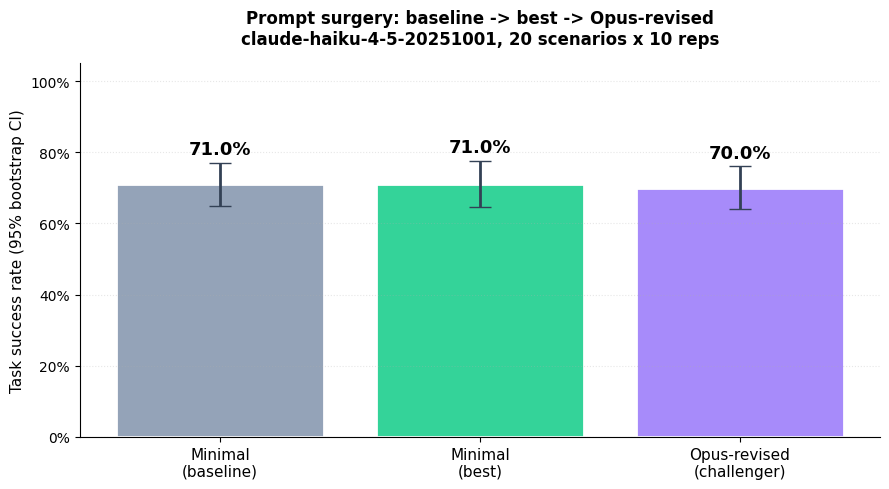

Saved: ps_beforeafter.png


In [20]:
# --- Figure 5: Before/after comparison ---
if revised_trajs:
    fig, ax = plt.subplots(figsize=(9, 5))

    compare_strategies = ["minimal", best_strategy, "opus_revised"]
    compare_labels = ["Minimal\n(baseline)", f"{best_strategy.capitalize()}\n(best)", "Opus-revised\n(challenger)"]
    bar_colors = ["#94a3b8", "#34d399", "#a78bfa"]

    means, lows, highs = [], [], []
    for strat in compare_strategies:
        if strat in strategy_outcomes:
            oc = strategy_outcomes[strat]
        else:
            oc = outcomes_array(all_trajs[strat])
        m, lo, hi = bootstrap_rate(oc, rng=rng)
        means.append(m); lows.append(lo); highs.append(hi)

    x = np.arange(len(compare_strategies))
    err_lo = [m - lo for m, lo in zip(means, lows)]
    err_hi = [hi - m for m, hi in zip(means, highs)]

    ax.bar(x, means, color=bar_colors, edgecolor="white", linewidth=2,
           yerr=[err_lo, err_hi], capsize=8,
           error_kw={"linewidth": 2, "ecolor": "#334155"})

    for i, (m, hi) in enumerate(zip(means, highs)):
        ax.text(x[i], hi + 0.025, f"{m:.1%}", ha="center", fontsize=13, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(compare_labels, fontsize=11)
    ax.set_ylabel("Task success rate (95% bootstrap CI)", fontsize=11)
    ax.set_title(f"Prompt surgery: baseline -> best -> Opus-revised\n{HAIKU_MODEL}, {N_SCENARIOS} scenarios x {N_REPLICATES} reps",
                 fontsize=12, fontweight="bold", pad=14)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(True, axis="y", alpha=0.3, linestyle=":")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig("ps_beforeafter.png", dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: ps_beforeafter.png")

## 12. Surgery report

In [21]:
def build_report() -> str:
    now = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
    lines = []
    lines.append("# Prompt Surgery Report")
    lines.append(f"_Generated {now}_")

    lines.append("\n## Study design")
    lines.append(f"- Primary model: `{HAIKU_MODEL}`")
    lines.append(f"- Cross-check model: `{SONNET_MODEL}`")
    lines.append(f"- Prompt surgeon: `{OPUS_MODEL}`")
    lines.append(f"- Task: airline booking agent, {len(TOOL_IMPL)} tools")
    lines.append(f"- Scenarios: {N_SCENARIOS} ({diff_counts})")
    lines.append(f"- Replicates per cell: {N_REPLICATES}")
    lines.append(f"- Temperature: {TEMPERATURE}")
    lines.append(f"- Bootstrap samples: {BOOT_SAMPLES}")
    lines.append(f"- N per strategy: {N_SCENARIOS * N_REPLICATES}")

    lines.append("\n## Statistical power")
    lines.append(f"With N={N_SCENARIOS * N_REPLICATES} binary outcomes per strategy and an expected baseline ")
    lines.append(f"rate of ~65%, the minimum detectable effect at 80% power (two-sided alpha=0.05) is ")
    lines.append(f"**{mde:.1%}**. This study is designed to detect real differences between structurally ")
    lines.append("distinct prompt strategies. Effects smaller than the MDE cannot be distinguished from noise ")
    lines.append("at this sample size; this does not mean they are zero.")

    lines.append("\n## Strategy results")
    lines.append("| Strategy | Success rate | 95% CI | Avg turns | Cost (200 trials) |")
    lines.append("|---|---|---|---|---|")
    for _, row in summary_df.iterrows():
        lines.append(f"| `{row['strategy']}` | {row['rate']:.1%} | [{row['ci_low']:.1%}, {row['ci_high']:.1%}] "
                     f"| {row['avg_turns']:.1f} | ${row['cost_usd']:.3f} |")

    lines.append("\n## Pairwise comparisons vs minimal baseline")
    lines.append("| Strategy | Delta | 95% CI | p-value | Verdict |")
    lines.append("|---|---|---|---|---|")
    for _, row in compare_df.iterrows():
        lines.append(f"| `{row['strategy']}` | {row['vs_baseline']:+.1%} | [{row['ci_low']:+.1%}, {row['ci_high']:+.1%}] "
                     f"| {row['p_value']:.3f} | **{row['verdict']}** |")

    lines.append("\n## Cross-model validation")
    lines.append(f"The best strategy (`{best_strategy}`) and the minimal baseline were re-run on `{SONNET_MODEL}`.")
    lines.append("")
    lines.append("| Strategy | Haiku rate | Sonnet rate | Sonnet 95% CI |")
    lines.append("|---|---|---|---|")
    for _, row in cross_df.iterrows():
        lines.append(f"| `{row['strategy']}` | {row['haiku_rate']:.1%} | {row['sonnet_rate']:.1%} "
                     f"| [{row['ci_low']:.1%}, {row['ci_high']:.1%}] |")
    lines.append("")
    lines.append(f"Sonnet delta ({best_strategy} vs minimal): {cdelta:+.1%} [{clo:+.1%}, {chi:+.1%}] p={cp:.3f}")
    if clo > 0:
        lines.append("\n**Effect replicates on Sonnet** (CI excludes zero).")
    else:
        lines.append("\nEffect does not reach significance on Sonnet at this N. The direction is consistent but "
                     "the magnitude appears smaller or more model-specific.")

    lines.append("\n## Opus-proposed revision")
    lines.append(f"**Reasoning:** {revision.get('reasoning', '(none)')}")
    lines.append("\n**Key changes:**")
    for ch in revision.get("key_changes", []):
        lines.append(f"- {ch}")
    if revised_trajs:
        lines.append(f"\n**Validation vs best strategy (`{best_strategy}`):** "
                     f"Opus-revised={rev_mean:.1%}, best={best_oc.mean():.1%}, "
                     f"delta={rdelta:+.1%} [{rci_lo:+.1%}, {rci_hi:+.1%}] p={rp:.3f}")
        if rci_lo > 0:
            lines.append("Revision **significantly outperforms** the best strategy.")
        elif rci_hi < 0:
            lines.append("Revision is **significantly worse** than the best strategy.")
        else:
            lines.append("Revision is **not significantly different** from the best strategy. "
                         "Both are improvements over minimal; the marginal gain of the revision "
                         "is smaller than the MDE at N=200.")

    # Cost summary — collect all trajectories
    all_t = [t for trajs in all_trajs.values() for t in trajs]
    cross_t = [t for trajs in cross_trajs.values() for t in trajs]
    agent_cost = sum(traj_cost(t) for t in all_t + cross_t)
    total_cost = agent_cost + opus_cost
    total_runs  = len(all_t) + len(cross_t)

    lines.append("\n## Study footprint")
    lines.append(f"- Total trajectory runs: {total_runs}")
    lines.append(f"- Agent API cost: ${agent_cost:.4f}")
    lines.append(f"- Opus revision cost: ${opus_cost:.4f}")
    lines.append(f"- **Grand total: ${total_cost:.4f}**")

    return "\n".join(lines)

report_text = build_report()
with open("SURGERY_REPORT.md", "w") as f:
    f.write(report_text)
print("Wrote SURGERY_REPORT.md")
print()
print(report_text)

Wrote SURGERY_REPORT.md

# Prompt Surgery Report
_Generated 2026-04-21 19:52 UTC_

## Study design
- Primary model: `claude-haiku-4-5-20251001`
- Cross-check model: `claude-sonnet-4-5-20250929`
- Prompt surgeon: `claude-opus-4-5-20251101`
- Task: airline booking agent, 6 tools
- Scenarios: 20 ({'easy': 8, 'medium': 9, 'hard': 3})
- Replicates per cell: 10
- Temperature: 0.4
- Bootstrap samples: 2000
- N per strategy: 200

## Statistical power
With N=200 binary outcomes per strategy and an expected baseline 
rate of ~65%, the minimum detectable effect at 80% power (two-sided alpha=0.05) is 
**13.4%**. This study is designed to detect real differences between structurally 
distinct prompt strategies. Effects smaller than the MDE cannot be distinguished from noise 
at this sample size; this does not mean they are zero.

## Strategy results
| Strategy | Success rate | 95% CI | Avg turns | Cost (200 trials) |
|---|---|---|---|---|
| `minimal` | 71.0% | [65.0%, 77.5%] | 2.1 | $0.661 |
| `ins

## 13. Save artifacts

In [22]:
# Save all trajectory data as JSON for offline analysis
def traj_to_dict(t: Trajectory) -> dict:
    return {
        "scenario_id":   t.scenario_id,
        "strategy":      t.strategy,
        "model":         t.model,
        "replicate":     t.replicate,
        "success":       t.success,
        "turns_used":    t.turns_used,
        "input_tokens":  t.input_tokens,
        "output_tokens": t.output_tokens,
        "latency_s":     round(t.latency_s, 2),
        "error":         t.error,
    }

all_traj_list = (
    [t for trajs in all_trajs.values() for t in trajs]
    + [t for trajs in cross_trajs.values() for t in trajs]
)

with open("trajectories.json", "w") as f:
    json.dump([traj_to_dict(t) for t in all_traj_list], f, indent=2)

summary_df.to_csv("strategy_summary.csv", index=False)
compare_df.to_csv("pairwise_comparisons.csv", index=False)
cross_df.to_csv("cross_model_results.csv", index=False)

if revision:
    with open("opus_revision.json", "w") as f:
        json.dump(revision, f, indent=2)

print("Saved:")
print("  trajectories.json          — all trial data")
print("  strategy_summary.csv       — per-strategy rates and CIs")
print("  pairwise_comparisons.csv   — vs-baseline comparisons")
print("  cross_model_results.csv    — Haiku vs Sonnet results")
print("  opus_revision.json         — Opus-proposed prompt revision")
print("  SURGERY_REPORT.md          — full narrative report")
print("  ps_strategy_comparison.png — main results figure")
print("  ps_heatmap.png             — per-scenario breakdown")
print("  ps_forest_plot.png         — pairwise effects")
print("  ps_cost_perf.png           — cost vs performance")
print("  ps_beforeafter.png         — baseline/best/revised comparison")

Saved:
  trajectories.json          — all trial data
  strategy_summary.csv       — per-strategy rates and CIs
  pairwise_comparisons.csv   — vs-baseline comparisons
  cross_model_results.csv    — Haiku vs Sonnet results
  opus_revision.json         — Opus-proposed prompt revision
  SURGERY_REPORT.md          — full narrative report
  ps_strategy_comparison.png — main results figure
  ps_heatmap.png             — per-scenario breakdown
  ps_forest_plot.png         — pairwise effects
  ps_cost_perf.png           — cost vs performance
  ps_beforeafter.png         — baseline/best/revised comparison
